In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import imageio
import pandas as pd
import pickle
import math


In [2]:
tmp = pickle.load(open('/Users/jinhao/decompose/benchmark_new/basic_maps.pkl', 'rb'))

In [3]:
import os
import numpy as np
import pickle

def is_valid_room_placement(start, goal, obstacle_centers, is_horizontal):
    """
    判断起点和终点是否在相邻区域
    
    参数:
    start: 起点坐标 [x, y]
    goal: 终点坐标 [x, y]
    obstacle_centers: 障碍物中心点列表 [(x1, y1), (x2, y2)]
    is_horizontal: 布尔值，表示障碍物是水平(True)还是垂直(False)
    
    返回:
    bool: 如果在合理的相邻区域则返回True，否则返回False
    """
    # 对于水平障碍物，使用x=0作为区分线
    if is_horizontal:
        # 获取两个障碍物的y坐标
        y1, y2 = sorted([center[1] for center in obstacle_centers])
        
        # 定义区域编号：
        # 1: 上部区域 (y > y2)
        # 2: 中部区域 (y1 < y < y2)
        # 3: 下部区域 (y < y1)
        # 加上垂直线x=0的划分，共6个区域
        
        def get_region_h(point):
            x, y = point
            if y > y2:
                return "1左" if x < 0 else "1右"
            elif y1 < y < y2:
                return "2左" if x < 0 else "2右"
            else:  # y < y1
                return "3左" if x < 0 else "3右"
        
        start_region = get_region_h(start)
        goal_region = get_region_h(goal)
        
        # 相邻区域定义
        adjacent_regions = {
            "1左": ["2左"],
            "2左": ["1左", "3左"],
            "3左": ["2左"],
            "1右": ["2右"],
            "2右": ["1右", "3右"],
            "3右": ["2右"]
        }
        
        return goal_region in adjacent_regions[start_region]
    
    # 对于垂直障碍物，使用y=0作为区分线
    else:
        # 获取两个障碍物的x坐标
        x1, x2 = sorted([center[0] for center in obstacle_centers])
        
        # 定义区域编号：
        # 1: 左侧区域 (x < x1)
        # 2: 中部区域 (x1 < x < x2)
        # 3: 右侧区域 (x > x2)
        # 加上水平线y=0的划分，共6个区域
        
        def get_region_v(point):
            x, y = point
            if x < x1:
                return "1上" if y > 0 else "1下"
            elif x1 < x < x2:
                return "2上" if y > 0 else "2下"
            else:  # x > x2
                return "3上" if y > 0 else "3下"
        
        start_region = get_region_v(start)
        goal_region = get_region_v(goal)
        
        # 相邻区域定义
        adjacent_regions = {
            "1上": ["2上"],
            "2上": ["1上", "3上"],
            "3上": ["2上"],
            "1下": ["2下"],
            "2下": ["1下", "3下"],
            "3下": ["2下"]
        }
        
        return goal_region in adjacent_regions[start_region]

# 离散网格中心（步长 0.1，从 -0.95 到 0.95）
grid_vals = np.arange(-0.95, 0.951, 0.1)
grid_centers = [(round(x,2), round(y,2)) for x in grid_vals for y in grid_vals]

# 两种长方形厚度（宽度）
width_options = [0.3, 0.4]

# 用于生成障碍物位置
pos_list_hor = np.linspace(-0.5, 0.5, 3)  # 水平障碍物的位置选项
pos_list_ver = np.linspace(-0.6, 0.6, 3)  # 垂直障碍物的位置选项

agent_rad = 0.05
num_agents = 20

instance_set = []

# 固定障碍物宽度
obstacle_width = 0.3  # 替代之前的width_options
obstacle_gap = 0.4    # 两个障碍物之间的固定间距

# 用于生成障碍物位置的基准点
pos_base = 0.0  # 中心点

# 固定障碍物宽度
obstacle_width = 0.4  # 障碍物宽度固定为0.3 (即3个网格单位)
obstacle_gap = 0.4    # 两个障碍物之间的固定间距

# 障碍物长度选项
length_options = [1.2, 1.4]  # 固定为1.2或1.4

# 网格步长
grid_step = 0.1  # 网格的步长为0.1

# 生成实例，一半是水平障碍物，一半是垂直障碍物
for instance_idx in range(25):
    # 决定障碍物是水平还是垂直 
    is_horizontal = (instance_idx % 2 == 0)
    
    if is_horizontal:
        # 对于宽度为0.3的障碍物，中心应该位于0.05的位置（网格中间）
        # 计算两个水平障碍物的y坐标
        half_gap_plus_width = (obstacle_width + obstacle_gap) / 2
        
        # 计算中心位置，确保障碍物边缘对齐网格
        # 首先计算大致位置
        base_y1 = pos_base - half_gap_plus_width
        base_y2 = pos_base + half_gap_plus_width
        
        # 将位置调整到最近的网格边缘，然后偏移0.05使中心在小格子中间
        y_center1 = round(base_y1 / grid_step) * grid_step 
        y_center2 = round(base_y2 / grid_step) * grid_step 
        
        y_centers = [y_center1, y_center2]
        
        # 从固定选项中选择障碍物长度
        lengths = [np.random.choice(length_options) for _ in range(2)]
        
        # 障碍物的x中心位置，确保在网格线的中点
        # 随机选择一个网格线，然后加上0.05偏移
        x_centers = [round(np.random.uniform(-0.1, 0.1) / grid_step) * grid_step for _ in range(2)]
        
        # 计算障碍物边界
        obstacles = []
        obstacle_centers = []
        
        for i in range(2):
            half_width = obstacle_width / 2
            half_length = lengths[i] / 2
            x_center = x_centers[i]
            y_center = y_centers[i]
            
            # 保存障碍物中心
            obstacle_centers.append((x_center, y_center))
            
            # 计算水平长方形的顶点：[tl, bl, br, tr]
            rect = [
                (x_center - half_length, y_center + half_width),
                (x_center - half_length, y_center - half_width),
                (x_center + half_length, y_center - half_width),
                (x_center + half_length, y_center + half_width),
            ]
            obstacles.append(rect)
    else:
        # 对于宽度为0.3的障碍物，中心应该位于0.05的位置（网格中间）
        # 计算两个垂直障碍物的x坐标
        half_gap_plus_width = (obstacle_width + obstacle_gap) / 2
        
        # 计算中心位置，确保障碍物边缘对齐网格
        # 首先计算大致位置
        base_x1 = pos_base - half_gap_plus_width
        base_x2 = pos_base + half_gap_plus_width
        
        # 将位置调整到最近的网格边缘，然后偏移0.05使中心在小格子中间
        x_center1 = round(base_x1 / grid_step) * grid_step 
        x_center2 = round(base_x2 / grid_step) * grid_step 
        
        x_centers = [x_center1, x_center2]
        
        # 从固定选项中选择障碍物长度
        lengths = [np.random.choice(length_options) for _ in range(2)]
        
        # 障碍物的y中心位置，确保在网格线的中点
        # 随机选择一个网格线，然后加上0.05偏移
        y_centers = [round(np.random.uniform(-0.1, 0.1) / grid_step) * grid_step for _ in range(2)]
        
        # 计算障碍物边界
        obstacles = []
        obstacle_centers = []
        
        for i in range(2):
            half_width = obstacle_width / 2
            half_length = lengths[i] / 2
            x_center = x_centers[i]
            y_center = y_centers[i]
            
            # 保存障碍物中心
            obstacle_centers.append((x_center, y_center))
            
            # 计算垂直长方形的顶点：[tl, bl, br, tr]
            rect = [
                (x_center - half_width, y_center + half_length),
                (x_center - half_width, y_center - half_length),
                (x_center + half_width, y_center - half_length),
                (x_center + half_width, y_center + half_length),
            ]
            obstacles.append(rect)

    # 过滤出不与任一障碍重叠的网格中心
    free_points = []
    for (x, y) in grid_centers:
        is_free = True
        for obstacle in obstacles:
            # 简化的碰撞检测：检查点到障碍物的距离
            # 如果点在任何障碍物的膨胀区域内，则不可用
            tl, bl, br, tr = obstacle
            
            # 检查点是否在扩展的矩形内
            min_x = min(tl[0], bl[0], br[0], tr[0]) - agent_rad - 0.05
            max_x = max(tl[0], bl[0], br[0], tr[0]) + agent_rad + 0.05
            min_y = min(tl[1], bl[1], br[1], tr[1]) - agent_rad - 0.05
            max_y = max(tl[1], bl[1], br[1], tr[1]) + agent_rad + 0.05
            
            if min_x <= x <= max_x and min_y <= y <= max_y:
                is_free = False
                break
        
        if is_free:
            free_points.append((x, y))

    # 确保每个起点和终点之间保持最小距离
    min_dist = 0.11
    starts = []
    goals = []

    # 随机生成每个机器人的起点和终点
    for _ in range(num_agents):
        # 选取起点
        valid_start = False
        while not valid_start:
            # 从可用点中随机选一个
            if len(free_points) == 0:
                break  # 若无可用点，则退出循环
            
            start_idx = np.random.randint(0, len(free_points))
            start_point = np.array(free_points[start_idx])
            
            # 检查与之前选取的所有起点和终点的距离
            valid_start = True
            for prev_start in starts:
                if np.linalg.norm(start_point - prev_start) < min_dist:
                    valid_start = False
                    break
            for prev_goal in goals:
                if np.linalg.norm(start_point - prev_goal) < min_dist:
                    valid_start = False
                    break
            
            if valid_start:
                # 不立即添加到starts，而是先找到合适的终点
                temp_start = start_point
                free_points.pop(start_idx)
                break
        
        # 如果找不到有效起点，则跳过此agent
        if not valid_start or len(free_points) == 0:
            continue
            
        # 选取终点
        valid_goal = False
        potential_goals = []
        
        # 首先筛选出符合距离要求的潜在终点
        for idx, point in enumerate(free_points):
            goal_point = np.array(point)
            dist_to_start = np.linalg.norm(goal_point - temp_start)
            
            # 确保起点和终点之间的距离在0.8到1.2之间
            if 0.8 <= dist_to_start <= 1.2:
                # 检查是否满足区域要求
                if is_valid_room_placement(temp_start, goal_point, obstacle_centers, is_horizontal):
                    potential_goals.append((idx, goal_point))
        
        # 如果没有满足条件的终点，则跳过此agent
        if not potential_goals:
            continue
            
        while not valid_goal and potential_goals:
            # 从满足条件的点中随机选一个
            goal_idx_in_potential = np.random.randint(0, len(potential_goals))
            orig_idx, goal_point = potential_goals[goal_idx_in_potential]
            
            # 检查与之前选取的所有起点和终点的距离
            valid_goal = True
            for prev_start in starts:
                if np.linalg.norm(goal_point - prev_start) < min_dist:
                    valid_goal = False
                    break
            for prev_goal in goals:
                if np.linalg.norm(goal_point - prev_goal) < min_dist:
                    valid_goal = False
                    break
                    
            if valid_goal:
                # 现在可以添加起点和终点了
                starts.append(temp_start)
                goals.append(goal_point)
                # 从可用点列表中移除已用的点
                free_points.pop(orig_idx - sum(1 for pg in potential_goals[:goal_idx_in_potential] 
                                            if pg[0] < orig_idx))
                break
            else:
                # 移除不符合条件的潜在终点
                potential_goals.pop(goal_idx_in_potential)

    # 组装 agent_info: [start, goal, radius]
    agent_info = [[s, g, agent_rad] for s, g in zip(starts, goals)]

    # 将障碍物和 agent_info 放入 instance
    instance_set.append([obstacles, agent_info])

# 保存到本地文件
os.makedirs('./benchmark_new', exist_ok=True)
with open('./benchmark_new/shelf_maps_new.pkl', 'wb') as f:
    pickle.dump(instance_set, f)

print(f'共生成 {len(instance_set)} 个货架地图，其中包含水平障碍物地图 {sum(1 for i in range(len(instance_set)) if i % 2 == 0)} 个，'
      f'垂直障碍物地图 {sum(1 for i in range(len(instance_set)) if i % 2 != 0)} 个')

共生成 25 个货架地图，其中包含水平障碍物地图 13 个，垂直障碍物地图 12 个


In [4]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

with open('./benchmark_new/shelf_maps_new.pkl','rb') as f:
    instance_set = pickle.load(f)

agent_rad = 0.05
grid_step = 2 * agent_rad    # 0.1
grid_vals = np.arange(-1, 1+grid_step, grid_step)

for idx, (obstacles, agents) in enumerate(instance_set, start=1):
    fig, ax = plt.subplots(figsize=(6,6))

    # 画网格
    ax.set_xticks(grid_vals)
    ax.set_yticks(grid_vals)
    ax.grid(True, linewidth=0.5)

    # 画障碍
    for poly in obstacles:
        ax.add_patch(patches.Polygon(poly, closed=True,
                                     facecolor='lightgray',
                                     edgecolor='black'))

    # 为每个agent生成不同的颜色
    num_agents = len(agents)
    colors = plt.cm.rainbow(np.linspace(0, 1, num_agents))

    # 画机器人：实心圆为起点，空心圆为终点，同一agent用相同颜色，并用线连接
    for i, (s, g, r) in enumerate(agents):
        color = colors[i]
        
        # 画起点（实心圆）
        ax.add_patch(patches.Circle(s, r, facecolor=color, edgecolor='black', alpha=0.6))
        
        # 画终点（空心圆）
        ax.add_patch(patches.Circle(g, r, facecolor='none', edgecolor=color, linewidth=1.5))
        
        # 添加连接起点和终点的直线
        ax.plot([s[0], g[0]], [s[1], g[1]], color=color, linestyle='--', linewidth=0.8, alpha=0.7)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    # ax.axis('off')
    plt.tight_layout()
    if not os.path.exists('./benchmark_new/shelf_maps'):
        os.makedirs('./benchmark_new/shelf_maps')
    plt.savefig(f'./benchmark_new/shelf_maps/viz_map_{idx:02d}.png', dpi=200)
    plt.close()

In [ ]:
raise NotImplementedError

In [3]:
import os
import numpy as np
import pickle

def is_valid_room_placement(start, goal, x_center, y_center):
    """
    判断起点和终点是否在同一个房间或相邻的房间
    参数:
    start: 起点坐标 [x, y]
    goal: 终点坐标 [x, y]
    x_center: 竖直障碍物的中心x坐标
    y_center: 水平障碍物的中心y坐标
    
    返回:
    bool: 如果在同一房间或相邻房间则返回True，否则返回False
    """
    # 根据障碍物位置确定起点在哪个象限
    start_quadrant = get_quadrant(start, x_center, y_center)
    goal_quadrant = get_quadrant(goal, x_center, y_center)
    
    # # 如果在同一象限，则有效
    # if start_quadrant == goal_quadrant:
    #     return True
    
    # 判断是否在相邻象限
    # 相邻象限的关系: 1与2相邻，1与4相邻，2与3相邻，3与4相邻
    adjacent_quadrants = {
        1: [2, 4],
        2: [1, 3],
        3: [2, 4],
        4: [1, 3]
    }
    
    return goal_quadrant in adjacent_quadrants[start_quadrant]

def get_quadrant(point, x_center, y_center):
    """
    确定点在哪个象限
    象限定义:
    1: 右上 (x > x_center, y > y_center)
    2: 左上 (x < x_center, y > y_center)
    3: 左下 (x < x_center, y < y_center)
    4: 右下 (x > x_center, y < y_center)
    """
    x, y = point
    
    if x > x_center and y > y_center:
        return 1  # 右上
    elif x < x_center and y > y_center:
        return 2  # 左上
    elif x < x_center and y < y_center:
        return 3  # 左下
    else:  # x > x_center and y < y_center
        return 4  # 右下

# 离散网格中心（步长 0.05，从 -0.95 到 0.95）
grid_vals = np.arange(-0.95, 0.951, 0.1)
grid_centers = [(round(x,2), round(y,2)) for x in grid_vals for y in grid_vals]

# 两种长方形厚度（宽度）
width_options = [0.3, 0.4]

# 用于生成 5 个水平/竖直障碍中心位置
pos_list = np.linspace(-0.2, 0.3, 5)

agent_rad = 0.05
num_agents = 20

instance_set = []

for y_center_base in pos_list:
    for x_center_base in pos_list:
        # 随机选取障碍宽度
        w_h = np.random.choice(width_options)  # 水平障碍厚度
        w_v = np.random.choice(width_options)  # 竖直障碍厚度

        # 根据厚度调整中心位置
        if w_h == 0.4:
            # 如果厚度为0.2，中心点为0.1的整数倍
            y_center = round(y_center_base * 10) / 10
        else:  # w_h == 0.3
            # 如果厚度为0.3，中心点以0.05结尾
            y_center = round((y_center_base * 10) / 10, 2)
            if y_center * 100 % 10 != 5:  # 如果不以0.05结尾
                y_center = round(y_center - 0.05, 2) if y_center % 0.1 < 0.05 else round(y_center + 0.05, 2)
        
        if w_v == 0.4:
            # 如果厚度为0.2，中心点为0.1的整数倍
            x_center = round(x_center_base * 10) / 10
        else:  # w_v == 0.3
            # 如果厚度为0.3，中心点以0.05结尾
            x_center = round((x_center_base * 10) / 10, 2)
            if x_center * 100 % 10 != 5:  # 如果不以0.05结尾
                x_center = round(x_center - 0.05, 2) if x_center % 0.1 < 0.05 else round(x_center + 0.05, 2)


        half_h = w_h / 2
        half_v = w_v / 2

        left_boundary = np.random.choice([-0.8, -0.7])
        right_boundary = np.random.choice([0.7, 0.8])
        top_boundary = np.random.choice([0.7, 0.8])
        bottom_boundary = np.random.choice([-0.8, -0.7])
        
        # 计算水平长方形的顶点：[tl, bl, br, tr]
        hor_rect = [
            (left_boundary,  y_center + half_h),
            (left_boundary,  y_center - half_h),
            (right_boundary,  y_center - half_h),
            (right_boundary,  y_center + half_h),
        ]
        # 计算竖直长方形的顶点
        ver_rect = [
            (x_center - half_v,  top_boundary),
            (x_center - half_v,  bottom_boundary),
            (x_center + half_v,  bottom_boundary),
            (x_center + half_v,  top_boundary),
        ]

        # 过滤出不与任一障碍重叠的网格中心
        free_points = []
        for (x, y) in grid_centers:
            # 点到水平障碍的垂直距离必须超过半厚度 + 机器人半径
            if abs(y - y_center) < (half_h + agent_rad+ 0.05):
                continue
            # 点到竖直障碍的水平距离必须超过半厚度 + 机器人半径
            if abs(x - x_center) < (half_v + agent_rad+ 0.05):
                continue
            free_points.append((x, y))
        

        # 确保每个起点和终点之间保持0.05的最小距离
        min_dist = 0.11
        starts = []
        goals = []

        # 随机生成每个机器人的起点和终点
        for _ in range(num_agents):
            # 选取起点
            valid_start = False
            while not valid_start:
                # 从可用点中随机选一个
                if len(free_points) == 0:
                    break  # 若无可用点，则退出循环
                
                start_idx = np.random.randint(0, len(free_points))
                start_point = np.array(free_points[start_idx])
                
                # 检查与之前选取的所有起点和终点的距离
                valid_start = True
                for prev_start in starts:
                    if np.linalg.norm(start_point - prev_start) < min_dist:
                        valid_start = False
                        break
                for prev_goal in goals:
                    if np.linalg.norm(start_point - prev_goal) < min_dist:
                        valid_start = False
                        break
                
                if valid_start:
                    # 不立即添加到starts，而是先找到合适的终点
                    temp_start = start_point
                    free_points.pop(start_idx)
                    break
            
            # 如果找不到有效起点，则跳过此agent
            if not valid_start or len(free_points) == 0:
                continue
                
            # 选取终点
            valid_goal = False
            potential_goals = []
            
            # 首先筛选出符合距离要求的潜在终点
            for idx, point in enumerate(free_points):
                goal_point = np.array(point)
                dist_to_start = np.linalg.norm(goal_point - temp_start)
                
                # 确保起点和终点之间的距离在0.8到1.2之间
                if 0.8 <= dist_to_start <= 1.2:
                    if is_valid_room_placement(temp_start, goal_point, x_center, y_center):
                        potential_goals.append((idx, goal_point))
                    # potential_goals.append((idx, goal_point))
            
            # 如果没有满足距离条件的终点，则跳过此agent
            if not potential_goals:
                continue
                
            while not valid_goal and potential_goals:
                # 从满足距离条件的点中随机选一个
                goal_idx_in_potential = np.random.randint(0, len(potential_goals))
                orig_idx, goal_point = potential_goals[goal_idx_in_potential]
                
                # 检查与之前选取的所有起点和终点的距离
                valid_goal = True
                for prev_start in starts:
                    if np.linalg.norm(goal_point - prev_start) < min_dist:
                        valid_goal = False
                        break
                for prev_goal in goals:
                    if np.linalg.norm(goal_point - prev_goal) < min_dist:
                        valid_goal = False
                        break
                        
                if valid_goal:
                    # 现在可以添加起点和终点了
                    starts.append(temp_start)
                    goals.append(goal_point)
                    # 从可用点列表中移除已用的点
                    free_points.pop(orig_idx - sum(1 for pg in potential_goals[:goal_idx_in_potential] 
                                                if pg[0] < orig_idx))
                    break
                else:
                    # 移除不符合条件的潜在终点
                    potential_goals.pop(goal_idx_in_potential)
            
            # 如果无法找到合适的起点或终点，则停止添加更多机器人
            if len(starts) != len(goals):
                break

        # 组装 agent_info: [start, goal, radius]
        agent_info = [[s, g, agent_rad] for s, g in zip(starts, goals)]

        # 将两个长方形障碍和 agent_info 放入 instance
        obs_set = [hor_rect, ver_rect]
        instance_set.append([obs_set, agent_info])

# 保存到本地文件
os.makedirs('./benchmark_new', exist_ok=True)
with open('./benchmark_new/room_maps.pkl', 'wb') as f:
    pickle.dump(instance_set, f)

print(f'共生成 {len(instance_set)} 个房间地图，每个地图包含 {num_agents} 对起点/终点')

共生成 25 个房间地图，每个地图包含 20 对起点/终点


In [4]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

with open('./benchmark_new/room_maps.pkl','rb') as f:
    instance_set = pickle.load(f)

agent_rad = 0.05
grid_step = 2 * agent_rad    # 0.1
grid_vals = np.arange(-1, 1+grid_step, grid_step)

for idx, (obstacles, agents) in enumerate(instance_set, start=1):
    fig, ax = plt.subplots(figsize=(6,6))

    # 画网格
    ax.set_xticks(grid_vals)
    ax.set_yticks(grid_vals)
    ax.grid(True, linewidth=0.5)

    # 画障碍
    for poly in obstacles:
        ax.add_patch(patches.Polygon(poly, closed=True,
                                     facecolor='lightgray',
                                     edgecolor='black'))

    # 为每个agent生成不同的颜色
    num_agents = len(agents)
    colors = plt.cm.rainbow(np.linspace(0, 1, num_agents))

    # 画机器人：实心圆为起点，空心圆为终点，同一agent用相同颜色，并用线连接
    for i, (s, g, r) in enumerate(agents):
        color = colors[i]
        
        # 画起点（实心圆）
        ax.add_patch(patches.Circle(s, r, facecolor=color, edgecolor='black', alpha=0.6))
        
        # 画终点（空心圆）
        ax.add_patch(patches.Circle(g, r, facecolor='none', edgecolor=color, linewidth=1.5))
        
        # 添加连接起点和终点的直线
        ax.plot([s[0], g[0]], [s[1], g[1]], color=color, linestyle='--', linewidth=0.8, alpha=0.7)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    # ax.axis('off')
    plt.tight_layout()
    if not os.path.exists('./benchmark_new/room_maps'):
        os.makedirs('./benchmark_new/room_maps')
    plt.savefig(f'./benchmark_new/room_maps/viz_map_{idx:02d}.png', dpi=200)
    plt.close()

In [ ]:
raise NotImplementedError

In [10]:
import numpy as np
import pickle
from matplotlib.colors import hsv_to_rgb
import signal

colors20 = plt.get_cmap('tab20').colors
color_sets = colors20[:20]

# def is_valid_pos(pt, rad, circle_obs, square_obs, margin):
#     """
#     检查点 pt（半径 rad）是否在边界内且与已有障碍物不重叠。
#     注意：此函数将所有障碍物（圆形和方形）视为其轴对齐边界框（正方形）进行碰撞检测。
#     circle_obs: [ (np.array([cx, cy]), cr), ... ] -> Treated as square with center [cx, cy] and half-side cr
#     square_obs: [ [top_left, top_right, bottom_left, bottom_right], ... ] -> Treated as square based on vertices
#     """
#     x, y = pt
#     # Boundary check
#     if x - rad < -1 + margin or x + rad > 1 - margin \
#        or y - rad < -1 + margin or y + rad > 1 - margin:
#         return False

#     # Check collision with circle obstacles (treating as AABB squares)
#     for center, cr in circle_obs:
#         sx, sy = center # Circle center is the square center
#         half = cr      # Circle radius is the square half-side
#         if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
#             return False # Collision detected

#     # Check collision with square obstacles (using vertices to find AABB)
#     # square_obs now contains lists of vertices: [tl, bl, br, tr] (order from get_square_vertices)
#     for verts in square_obs:
#         # Calculate center (sx, sy) and half-side length from vertices
#         # Assumes verts = [top_left, bottom_left, bottom_right, top_right]
#         sx = (verts[0][0] + verts[3][0]) / 2 # Avg of top-left x and top-right x
#         sy = (verts[0][1] + verts[1][1]) / 2 # Avg of top-left y and bottom-left y
#         half = abs(verts[3][0] - verts[0][0]) / 2 # Half the distance between top-right x and top-left x

#         if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
#             return False # Collision detected

#     # No collision found with any obstacle
#     return True

def is_valid_pos(pt, rad, circle_obs, square_obs, margin, min_spacing_distance):
    """
    检查点 pt（半径 rad）是否有效：
    1. 在边界内。
    2. 与已有障碍物不碰撞 (基于AABB)。
    3. 与已有障碍物的中心保持最小间距。
    """
    x, y = pt
    pt_arr = np.array(pt) # 转换为 numpy array 以便计算距离

    # 1. Boundary check
    if x - rad < -0.95 + margin or x + rad > 0.95 - margin \
       or y - rad < -0.95 + margin or y + rad > 0.95 - margin:
        return False

    # 2. Check collision and minimum distance with circle obstacles
    for center, cr in circle_obs:
        sx, sy = center # Circle center
        half = cr      # Circle radius (used as half-side for AABB)
        # AABB Collision check
        if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
            return False # Collision detected
        # Minimum distance check (center to center)
        if np.linalg.norm(pt_arr - center) < min_spacing_distance:
             return False # Too close to another obstacle center

    # 3. Check collision and minimum distance with square obstacles
    for verts in square_obs:
        # Calculate center (sx, sy) and half-side length from vertices
        sx = (verts[0][0] + verts[3][0]) / 2
        sy = (verts[0][1] + verts[1][1]) / 2
        half = abs(verts[3][0] - verts[0][0]) / 2
        square_center = np.array([sx, sy])

        # AABB Collision check
        if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
            return False # Collision detected
        # Minimum distance check (center to center)
        if np.linalg.norm(pt_arr - square_center) < min_spacing_distance:
             return False # Too close to another obstacle center

    # All checks passed
    return True


def is_valid_agent(pt, rad, circle_obs, square_obs, agent_set, margin):
    """
    检查点 pt（半径 rad）是否在边界内且与已有障碍物不重叠。
    注意：此函数将所有障碍物（圆形和方形）视为其轴对齐边界框（正方形）进行碰撞检测。
    circle_obs: [ (np.array([cx, cy]), cr), ... ] -> Treated as square with center [cx, cy] and half-side cr
    square_obs: [ [top_left, top_right, bottom_left, bottom_right], ... ] -> Treated as square based on vertices
    """
    x, y = pt
    # Boundary check
    if x - rad < -1 + margin or x + rad > 1 - margin \
       or y - rad < -1 + margin or y + rad > 1 - margin:
        return False

    # Check collision with circle obstacles (treating as AABB squares)
    for center, cr in circle_obs:
        sx, sy = center # Circle center is the square center
        half = cr      # Circle radius is the square half-side
        if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
            return False # Collision detected
    
    # Check collision with other agents (treating as AABB squares)
    for start, goal, rad in agent_set:
        sx, sy = start
        gx, gy = goal
        half = rad
        if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
            return False # Collision detected
        if abs(x - gx) < half + rad + margin and abs(y - gy) < half + rad + margin:
            return False # Collision detected
    
    # Check collision with square obstacles (using vertices to find AABB)
    # square_obs now contains lists of vertices: [tl, bl, br, tr] (order from get_square_vertices)
    for verts in square_obs:
        # Calculate center (sx, sy) and half-side length from vertices
        # Assumes verts = [top_left, bottom_left, bottom_right, top_right]
        sx = (verts[0][0] + verts[3][0]) / 2 # Avg of top-left x and top-right x
        sy = (verts[0][1] + verts[1][1]) / 2 # Avg of top-left y and bottom-left y
        half = abs(verts[3][0] - verts[0][0]) / 2 # Half the distance between top-right x and top-left x

        if abs(x - sx) < half + rad + margin and abs(y - sy) < half + rad + margin:
            return False # Collision detected

    # No collision found with any obstacle
    return True

def get_square_vertices(cx, cy, side):
    """Calculates the four vertices of an axis-aligned square."""
    half = side / 2
    top_left = (round(cx - half, 2), round(cy + half, 2))
    top_right = (round(cx + half, 2), round(cy + half, 2))
    bottom_left = (round(cx - half, 2), round(cy - half, 2))
    bottom_right = (round(cx + half, 2), round(cy - half, 2))
    return [top_left, bottom_left, bottom_right, top_right] # Return as list of tuples

type = 'dense'
if type == 'basic':
    prob = 0.4
    num_obs = 10
    min_spacing_distance = 0.4
    distance_threshold = 0.1
    margin = 0.05
elif type == 'dense':
    prob = 0.6
    num_obs = 20
    min_spacing_distance = 0
    distance_threshold = 0.25
    margin = 0.05


agent_rad = 0.05
num_agents = 20


instance_set = []

# 自定义超时异常
class TimeoutException(Exception):
    pass
# 信号处理函数：收到 SIGALRM 就抛出超时异常
def timeout_handler(signum, frame):
    raise TimeoutException()
# 注册 SIGALRM 信号处理器
signal.signal(signal.SIGALRM, timeout_handler)

while len(instance_set) < 50:
    # 设定 30 秒倒计时
    signal.alarm(30)
    try:

        # 两个候选网格：步长 0.1 的整数倍；步长 0.05 且排除 0.1 整数倍
        grid01 = np.arange(-0.9, 0.9001, 0.1)
        grid05 = np.arange(-0.95, 0.9501, 0.1)
        # centers01: 所有 (x,y) 二元元组, 保留两位小数
        centers01 = [(round(float(x), 2), round(float(y), 2)) for x in grid01 for y in grid01]
        # centers05: 排除恰好是 0.1 倍数的点, 保留两位小数
        centers05 = [
            (round(float(x), 2), round(float(y), 2))
            for x in grid05 for y in grid05
            if not np.isclose((x * 10) % 1, 0.0, atol=1e-8) # The check still uses original precision
        ]


        circle_obs = []
        square_obs = []


        # 生成 5 个圆形：半径随机取 0.1 或 0.05
        for _ in range(int(num_obs/2)):
            if np.random.rand() < prob:
                r = 0.05
            else:
                r = 0.1
            pool = centers01 if np.isclose(r, 0.1) else centers05
            
            # 从还没用过的点里挑一个
            length = len(pool)
            # 随机生成一个0-length-1的整数
            while True:
                random_idx = np.random.randint(0, length)
                avail = pool[random_idx]
                if is_valid_pos(avail, r, circle_obs, square_obs, margin, min_spacing_distance):
                    # 确定使用的哪个候选网格
                    if np.isclose(r, 0.1):
                        centers01.remove(avail)
                    else:
                        centers05.remove(avail)
                    break
            
            circle_obs.append((np.array(avail), r))


        # 生成 5 个正方形：边长随机取 0.2 或 0.1
        for _ in range(int(num_obs/2)):
            if np.random.rand() < prob:
                s = 0.1
            else:
                s = 0.2
            pool = centers01 if np.isclose(s, 0.2) else centers05

            length = len(pool)
            while True:
                random_idx = np.random.randint(0, length)
                avail = pool[random_idx]
                if is_valid_pos(avail, s/2, circle_obs, square_obs, margin, min_spacing_distance):
                    # 确定使用的哪个候选网格
                    if np.isclose(s, 0.2):
                        centers01.remove(avail)
                    else:
                        centers05.remove(avail)
                    break
            
            vertices = get_square_vertices(avail[0], avail[1], s)
            square_obs.append(vertices)



        # 生成 20 个智能体：起点/终点来自步长 0.05、排除 0.1 整数倍
        coords_agent = centers05  # 已经是排除整数倍 0.1 的步长 0.05 网格

        agent_info = []
        while len(agent_info) < num_agents:

            while True:
                random_idx = np.random.randint(0, len(coords_agent))
                avail = coords_agent[random_idx]
                if is_valid_agent(avail, agent_rad, circle_obs, square_obs, agent_info, margin):
                    coords_agent.remove(avail)
                    break
            sx, sy = avail
            start = np.array([sx, sy])

            # while True: 
            #     random_idx = np.random.randint(0, len(coords_agent))
            #     avail = coords_agent[random_idx]
            #     if is_valid_agent(avail, agent_rad, circle_obs, square_obs, agent_info, margin):
            #         coords_agent.remove(avail)
            #         break
            # gx, gy = avail
            # 筛选在指定距离范围内的点作为潜在终点
            potential_goals = []
            for point in coords_agent:
                gx, gy = point
                goal = np.array([gx, gy])
                d = np.linalg.norm(start - goal)
                
                # 检查距离是否在要求范围内
                if 1-distance_threshold <= d <= 1+distance_threshold:
                    potential_goals.append(point)

            # 如果有符合距离要求的点，从中随机选择一个作为终点
            if potential_goals:
                found_goal = False
                # 随机打乱潜在终点列表，以增加随机性
                np.random.shuffle(potential_goals)
                
                for goal_point in potential_goals:
                    if is_valid_agent(goal_point, agent_rad, circle_obs, square_obs, agent_info, margin):
                        gx, gy = goal_point
                        goal = np.array([gx, gy])
                        coords_agent.remove(goal_point)  # 从可用点中移除
                        found_goal = True
                        break
            else:
                continue

            # goal  = np.array([gx, gy])
            # d = np.linalg.norm(start - goal)
            # if d < 1-distance_threshold or d > 1+distance_threshold:
            #     continue
            
            # if not is_valid_agent(start, agent_rad, circle_obs, square_obs, agent_info, margin):
            #     continue
            # if not is_valid_agent(goal,  agent_rad, circle_obs, square_obs, agent_info, margin):
            #     continue
            # # 与已有智能体冲突检查
            # conflict = False
            # for s_arr, g_arr, _ in agent_info:
            #     if (np.linalg.norm(start - s_arr) < 2*agent_rad + margin or
            #         np.linalg.norm(start - g_arr) < 2*agent_rad + margin or
            #         np.linalg.norm(goal  - s_arr) < 2*agent_rad + margin or
            #         np.linalg.norm(goal  - g_arr) < 2*agent_rad + margin):
            #         conflict = True
            #         break
            # if conflict:
            #     continue
            agent_info.append([start, goal, agent_rad])
            

        # 将两个列表合并
        obs_set = []
        for i in range(len(circle_obs)):
            obs_set.append(circle_obs[i])
        for i in range(len(square_obs)):
            obs_set.append(square_obs[i])
        instance_set.append([obs_set, agent_info])


        # 可视化障碍物
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 绘制圆形障碍物
        for center, rad in circle_obs:
            circle = patches.Circle(center, rad, edgecolor=None, facecolor='wheat')
            ax.add_patch(circle)

        # 绘制正方形障碍物
        for vertices in square_obs:
            rect = patches.Polygon(vertices, edgecolor=None, facecolor='wheat')
            ax.add_patch(rect)


        # x和y轴范围
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)

        # 移除坐标轴
        ax.set_axis_off()
        
        # 移除边框
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # 移除网格
        ax.grid(False)
        
        # 确保图像紧凑，没有多余的空白边缘
        plt.tight_layout()
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

        if not os.path.exists(f'./benchmark_new/{type}_maps'):
            os.makedirs(f'./benchmark_new/{type}_maps')
        plt.savefig(f'./benchmark_new/{type}_maps/{type}_map_{len(instance_set)}.png', dpi=300)

        plt.close()


        # 可视化障碍物
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 绘制圆形障碍物
        for center, rad in circle_obs:
            circle = patches.Circle(center, rad, edgecolor=None, facecolor='wheat')
            ax.add_patch(circle)

        # 绘制正方形障碍物
        for vertices in square_obs:
            rect = patches.Polygon(vertices, edgecolor=None, facecolor='wheat')
            ax.add_patch(rect)

        # 绘制智能体
        for i in range(len(agent_info)):
            start, goal, rad = agent_info[i]
            circle = patches.Circle(start, rad, edgecolor=color_sets[i], facecolor=color_sets[i])
            ax.add_patch(circle)
            circle = patches.Circle(goal, rad, edgecolor=color_sets[i], facecolor='None')
            ax.add_patch(circle)

        # # 只能体起点和终点连一条线
        # for i in range(len(agent_info)):
        #     start, goal, rad = agent_info[i]
        #     plt.plot([start[0], goal[0]], [start[1], goal[1]], color=color_sets[i])

        # x和y轴范围
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)

        # 移除坐标轴
        ax.set_axis_off()
        
        # 移除边框
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # 移除网格
        ax.grid(False)
        
        # 确保图像紧凑，没有多余的空白边缘
        plt.tight_layout()
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

        plt.savefig(f'./benchmark_new/{type}_maps/{type}_instances_{len(instance_set)}.png', dpi=300)

        plt.close()

        print(f'{len(instance_set)} instances generated')

        pass

    except TimeoutException:
        print("本次循环超时，已跳过")
        continue

    finally:
        signal.alarm(0)
# 将instance_set保存至npy
# 第一层列表中保存50个不同的instance
# 第二层列表中保存同一个地图有三种不同数量的agent
# 第三层列表中的第一个元素是障碍物，第二个元素是智能体
# 第四层列表中的第一个元素是障碍物的位置和半径，第二个元素是智能体的起点，终点，半径
with open(f'./benchmark_new/{type}_maps.pkl', 'wb') as f:
    pickle.dump(instance_set, f)


1 instances generated
本次循环超时，已跳过
2 instances generated
3 instances generated
4 instances generated
5 instances generated
6 instances generated
7 instances generated
8 instances generated
9 instances generated
10 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
11 instances generated
12 instances generated
13 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
14 instances generated
15 instances generated
16 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
17 instances generated
18 instances generated
19 instances generated
20 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
21 instances generated
22 instances generated
本次循环超时，已跳过
23 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
24 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
25 instances generated
本次循环超时，已跳过
本次循环超时，已跳过
本次循环超时，已跳过
26 instances generated
27 instances generated
本次循环超时，已跳过
28 instances generated
29 instances generated
30 instances generated
本次循环超时，已跳过
31 instances generated
32 instances generate

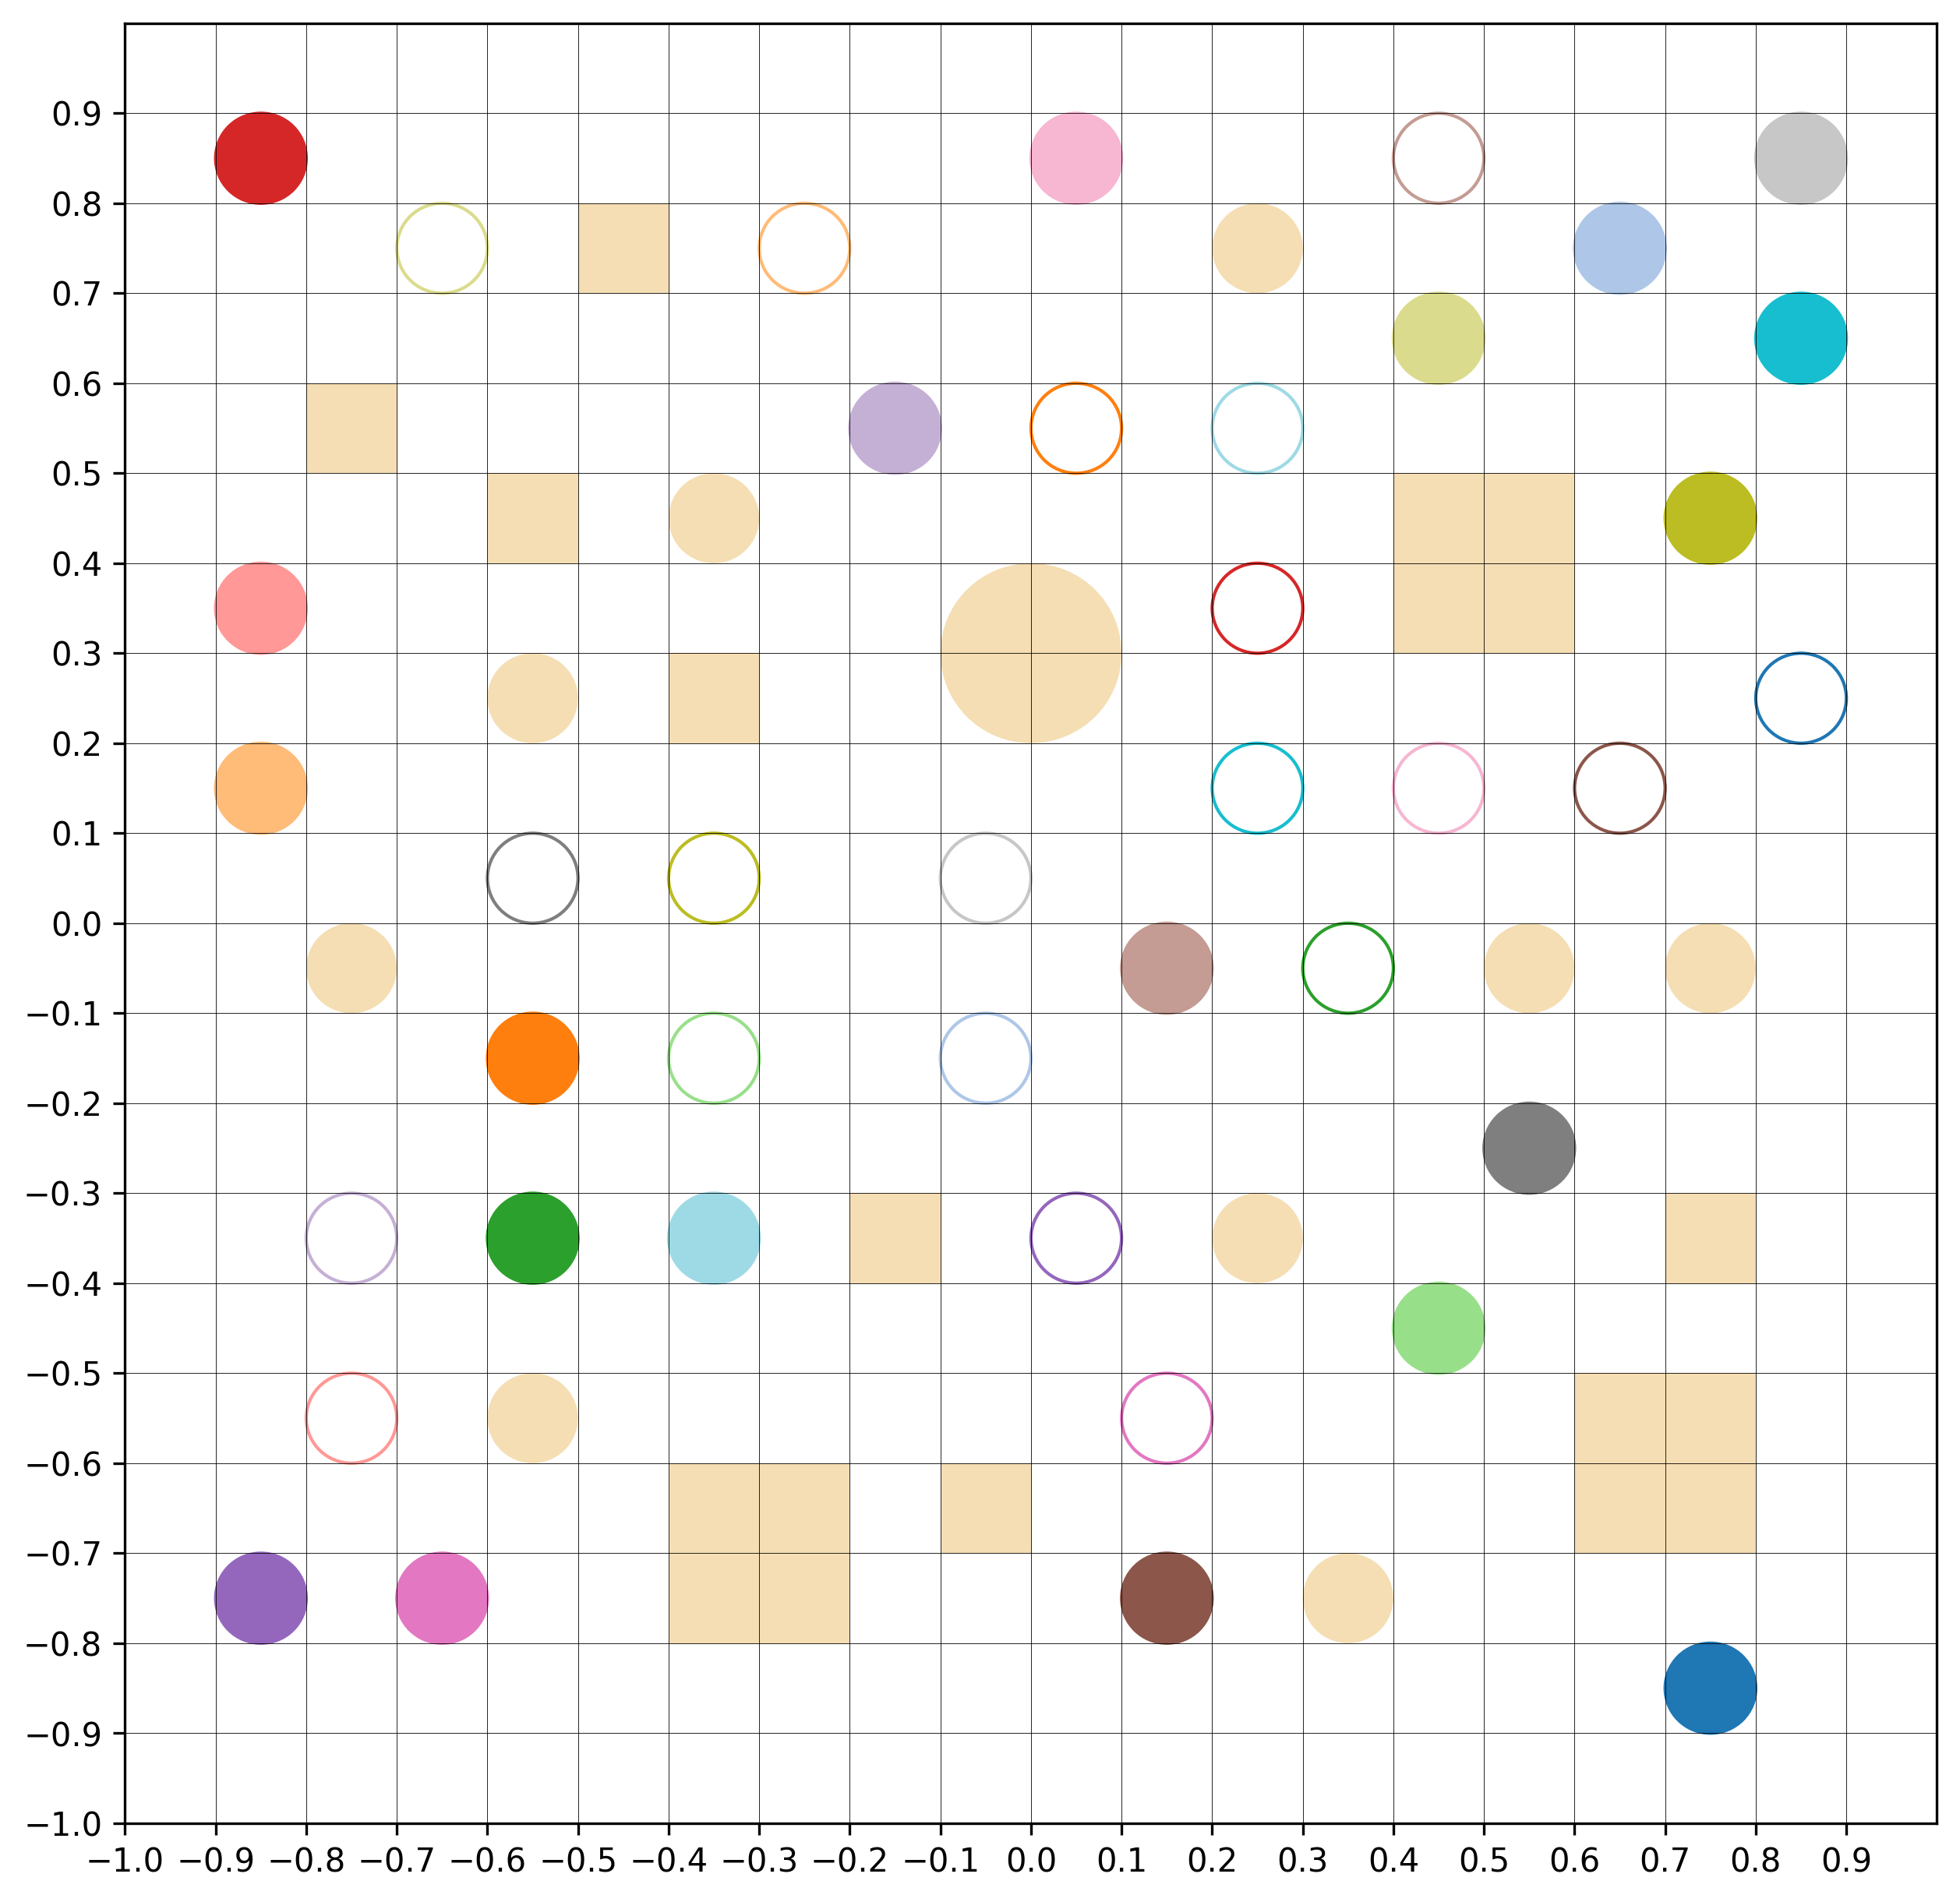

In [24]:
# 读取生成的实例
import pickle
colors20 = plt.get_cmap('tab20').colors
color_sets = colors20[:20]

basic_data = pickle.load(open(f'./benchmark_new/basic_maps.pkl', 'rb'))
dense_data = pickle.load(open(f'./benchmark_new/dense_maps.pkl', 'rb'))


for i in range(0,1):
        obs_list, agent_list = dense_data[i][0], dense_data[i][1]
        # 可视化障碍物
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 绘制圆形障碍物,前一半是圆形，后一半是正方形
        for center, rad in obs_list[:len(obs_list)//2]:
            circle = patches.Circle(center, rad, edgecolor=None, facecolor='wheat')
            ax.add_patch(circle)

        # 绘制正方形障碍物
        for vertices in obs_list[len(obs_list)//2:]:
            rect = patches.Polygon(vertices, edgecolor=None, facecolor='wheat')
            ax.add_patch(rect)

        # 绘制智能体
        for i in range(len(agent_list)):
            start, goal, rad = agent_list[i]
            circle = patches.Circle(start, rad, edgecolor=color_sets[i], facecolor=color_sets[i])
            ax.add_patch(circle)
            circle = patches.Circle(goal, rad, edgecolor=color_sets[i], facecolor='None')
            ax.add_patch(circle)

        # x和y轴范围
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)

        # 设置主刻度
        ax.set_xticks(np.arange(-1, 1, 0.1))
        ax.set_yticks(np.arange(-1, 1, 0.1))

        # 显示网格线，指定使用主刻度的网格线
        ax.grid(which='major', linewidth=0.2, color='black')
        plt.show()


        # if not os.path.exists(f'./benchmark_new/{type}_maps'):
        #     os.makedirs(f'./benchmark_new/{type}_maps')
        # plt.savefig(f'./benchmark_new/{type}_maps/{type}_map_{len(instance_set)}.png', dpi=300)


In [25]:
agent_list

[[array([ 0.75, -0.85]), array([0.85, 0.25]), 0.05],
 [array([0.65, 0.75]), array([-0.05, -0.15]), 0.05],
 [array([-0.55, -0.15]), array([0.05, 0.55]), 0.05],
 [array([-0.85,  0.15]), array([-0.25,  0.75]), 0.05],
 [array([-0.55, -0.35]), array([ 0.35, -0.05]), 0.05],
 [array([ 0.45, -0.45]), array([-0.35, -0.15]), 0.05],
 [array([-0.85,  0.85]), array([0.25, 0.35]), 0.05],
 [array([-0.85,  0.35]), array([-0.75, -0.55]), 0.05],
 [array([-0.85, -0.75]), array([ 0.05, -0.35]), 0.05],
 [array([-0.15,  0.55]), array([-0.75, -0.35]), 0.05],
 [array([ 0.15, -0.75]), array([0.65, 0.15]), 0.05],
 [array([ 0.15, -0.05]), array([0.45, 0.85]), 0.05],
 [array([-0.65, -0.75]), array([ 0.15, -0.55]), 0.05],
 [array([0.05, 0.85]), array([0.45, 0.15]), 0.05],
 [array([ 0.55, -0.25]), array([-0.55,  0.05]), 0.05],
 [array([0.85, 0.85]), array([-0.05,  0.05]), 0.05],
 [array([0.75, 0.45]), array([-0.35,  0.05]), 0.05],
 [array([0.45, 0.65]), array([-0.65,  0.75]), 0.05],
 [array([0.85, 0.65]), array([0.

In [ ]:
# # Room Instance Generation
# def is_valid_position(candidate_pos, candidate_rad, existing_list, margin):
#     """
#     检查 candidate_pos, candidate_rad 与已有实体之间是否重叠，
#     以及是否在给定边界内。
#     """
#     # 超过边界检查
#     if (candidate_pos[0] - candidate_rad < -1 + margin or
#         candidate_pos[0] + candidate_rad >  1 - margin or
#         candidate_pos[1] - candidate_rad < -1 + margin or
#         candidate_pos[1] + candidate_rad >  1 - margin):
#         return False
    
#     # 与已有障碍物或智能体重叠检查
#     for pos, rad in existing_list:
#         if np.linalg.norm(candidate_pos - pos) < candidate_rad + rad + margin:
#             return False
    
#     return True

# def from_sphere_to_square(center,radius):
#     square_side = radius * math.sqrt(2)

#     half_side = square_side / 2

#     top_left = (center[0] - half_side, center[1] + half_side)
#     top_right = (center[0] + half_side, center[1] + half_side)
#     bottom_left = (center[0] - half_side, center[1] - half_side)
#     bottom_right = (center[0] + half_side, center[1] - half_side)    

#     return top_left, top_right, bottom_left, bottom_right

# # num_obs = 20
# # num_agents_set = [3, 6, 9]
# # agent_rads = 0.07
# # obs_rads_base = 0.05
# # margin = 0.06

# # center_y_1 = [
# #                 [0.875,0.375,0.125,-0.125,-0.375,-0.875],
# #                 [0.875,0.625,0.125,-0.125,-0.625,-0.875],
# #                 [0.875,0.375,-0.125,-0.375,-0.625,-0.875],
# #                 [0.875,0.625,0.375,-0.125,-0.625,-0.875],
# #                 [0.875,0.625,0.375,-0.125,-0.375,-0.875]
# #             ]

# # center_y_2 = [
# #                 [0.875,0.375,-0.125,-0.375,-0.625,-0.875],
# #                 [0.875,0.625,0.375,0.125,-0.375,-0.875],
# #                 [0.875,0.625,0.125,-0.125,-0.375,-0.875],
# #                 [0.875,0.625,0.125,-0.375,-0.625,-0.875],
# #                 [0.875,0.375,0.125,-0.125,-0.625,-0.875]
# #             ] 
# center_y = [
#     [0.875,0.625,0.375,0.125, -0.125,-0.375],
#     [0.625,0.375,0.125,-0.125,-0.375,-0.625],
#     [0.375,0.125,-0.125,-0.375,-0.625,-0.875],
# ]
# center_x_1 = [
#     -0.5, -0.4, -0.3,
# ]
# center_x_2 = [
#     0.5, 0.4, 0.3,
# ]



# num_agents_set = [3, 6, 9]
# agent_rads = 0.05
# margin = 0.06
# candidate_rad = math.sqrt(2)/8
# instance_set = []
# instance_set_mix = []
# for i in range(len(center_y)):
#     for j in range(len(center_x_1)):
#         for k in range(len(center_x_2)):
#             # if i == 1 and j == 1 and k == 2:
#             #     continue
#             # if i == 1 and j == 2 and k == 1:
#             #     continue
#             if len(instance_set) % 10 == 0:
#                 print(len(instance_set))
#             if len(instance_set) >= 250:
#                 break
#             # 障碍物生成
#             obs_set = []
#             obs_set_mix = []

#             for idx_y in range(len(center_y[i])):
#                 obs_set.append([[center_x_1[j], center_y[i][idx_y]], candidate_rad])
#                 obs_set.append([[center_x_2[k], center_y[i][idx_y]], candidate_rad])

#             for idx in range(len(obs_set)):
#                 p1_0, p2_0, p3_0, p4_0 = from_sphere_to_square(obs_set[idx][0],candidate_rad)
#                 obs_set_mix.append([p1_0, p2_0, p3_0, p4_0])


#             # 将每一个position转化为array
#             for idx in range(len(obs_set)):
#                 obs_set[idx][0] = np.array(obs_set[idx][0])
#             for idx in range(len(obs_set_mix)):
#                 obs_set_mix[idx] = np.array(obs_set_mix[idx])

#             # fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
#             # plt.clf()  # 清除当前图形
#             # ax = plt.gca()  # 获取当前轴

#             # # for m in range(len(obs_set)):
#             # #     circle = patches.Circle(obs_set[m][0], obs_set[m][1], edgecolor='k', facecolor='k')
#             # #     ax.add_patch(circle)
#             # for m in range(len(obs_set_mix)):
#             #     # 坐标的排序是左上，右上，左下，右下
#             #     # polygon = patches.Polygon([obs_set_mix[m][0], obs_set_mix[m][2], obs_set_mix[m][3], obs_set_mix[m][1]], 
#             #     #                         closed=True, edgecolor='k', facecolor='k')
#             #     # center = np.mean([obs_set_mix[m][0], obs_set_mix[m][1], obs_set_mix[m][2], obs_set_mix[m][3]], axis=0)
#             #     # # print(f"Square {idx} center: {center}")
#             #     # ax.add_patch(polygon)
#             #     circle = patches.Circle(obs_set[m][0], obs_set[m][1], edgecolor='k', facecolor='k')
#             #     ax.add_patch(circle)

#             # # 添加网格线，两个线之间的距离为0.1
#             # ax.set_xticks(np.arange(-1, 1, 0.1))
#             # ax.set_yticks(np.arange(-1, 1, 0.1))
#             # ax.grid(color='gray', linestyle='--', linewidth=0.1)

#             # plt.xlim(-1,1)
#             # plt.ylim(-1,1)
#             # # plt.axis('off')
#             # # print(obs_set_mix)
#             # plt.show()
#             # plt.close('all')  # 关闭所有图形窗口

                
#             # continue

#                     # 对不同数量的智能体生成初始和目标位置
#             for agent_scenarios in range(10):
#                 instance = []
#                 instance_mix = []
#                 for num_agents in num_agents_set:
#                     agent_set = []
#                     while len(agent_set) < num_agents:
#                         # 在 [-1+margin, 1-margin] 范围采样
#                         if i== 0:
#                             agent_1 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  np.random.uniform(0.3, 0.95)])
#                             agent_2 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  np.random.uniform(-0.95,0)])

#                             agent_3 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  np.random.uniform(-0.95, -0.3)])
#                             agent_4 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  np.random.uniform(0.3, 0.95)])

#                             agent_5 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  np.random.uniform(-0.95,0)])
#                             agent_6 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  np.random.uniform(0.3, 0.95)])

#                             task = [[agent_1,agent_2],[agent_2,agent_3],[agent_3,agent_4],[agent_3,agent_5],[agent_5,agent_6]]
#                             # 随机选取一个
#                             order_idx = np.random.randint(0, len(task))
                        
#                             if np.random.uniform(0, 1) > 0.5:
#                                 agent_starts = task[order_idx][0]
#                                 agent_goals = task[order_idx][1]
#                             else:
#                                 agent_starts = task[order_idx][1]
#                                 agent_goals = task[order_idx][0]
                           
#                         elif i == 1:
#                             agent_1 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  np.random.uniform(0.2, 0.7)])
#                             agent_2 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  np.random.uniform(0.2, 0.7)])
#                             agent_3 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  np.random.uniform(0.2, 0.7)])
#                             agent_4 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  np.random.uniform(-0.7, -0.2)])
#                             agent_5 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  np.random.uniform(-0.7, -0.2)])
#                             agent_6 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  np.random.uniform(-0.7, -0.2)])

#                             task = [[agent_1,agent_2],[agent_2,agent_3],[agent_4,agent_5],[agent_5,agent_6],[agent_1,agent_4],[agent_2,agent_5],[agent_3,agent_6]]
#                             # 随机选取一个
#                             order_idx = np.random.randint(0, len(task))
#                             if np.random.uniform(0, 1) > 0.5:
#                                 agent_starts = task[order_idx][0]
#                                 agent_goals = task[order_idx][1]
#                             else:
#                                 agent_starts = task[order_idx][1]
#                                 agent_goals = task[order_idx][0]

#                         elif i == 2:

#                             agent_1 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  -np.random.uniform(0.3, 0.95)])
#                             agent_2 = np.array([np.random.uniform(-1, center_x_1[j] - 0.2 ),  -np.random.uniform(-0.95,0)])

#                             agent_3 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  -np.random.uniform(-0.95, -0.3)])
#                             agent_4 = np.array([np.random.uniform(center_x_1[j] + 0.2 , center_x_2[k] - 0.2),  -np.random.uniform(0.3, 0.95)])

#                             agent_5 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  -np.random.uniform(-0.95,0)])
#                             agent_6 = np.array([np.random.uniform(center_x_2[k] + 0.2, 1),  -np.random.uniform(0.3, 0.95)])

#                             task = [[agent_1,agent_2],[agent_2,agent_3],[agent_3,agent_4],[agent_3,agent_5],[agent_5,agent_6]]
#                             # 随机选取一个
#                             order_idx = np.random.randint(0, len(task))
                        
#                             if np.random.uniform(0, 1) > 0.5:
#                                 agent_starts = task[order_idx][0]
#                                 agent_goals = task[order_idx][1]
#                             else:
#                                 agent_starts = task[order_idx][1]
#                                 agent_goals = task[order_idx][0]


#                         if np.linalg.norm(agent_starts - agent_goals) > 1:
#                             continue
#                         # 检查与障碍物和已有智能体的重叠
#                         # 注意这里智能体的数据结构是 [pos_start, pos_goal, rad]
#                         # 要检查起点与障碍物和其他智能体，以及终点与障碍物和其他智能体是否重叠
#                         if not is_valid_position(agent_starts, agent_rads, obs_set, margin):
#                             continue
#                         if not is_valid_position(agent_goals, agent_rads, obs_set, margin):
#                             continue
#                         # 再与现有智能体的起终点重叠检查
#                         # 对现有智能体的每个 [pos_start, pos_goal, rad] 都要检查
#                         overlap_flag = False
#                         for asg in agent_set:
#                             if (np.linalg.norm(agent_starts - asg[0]) < agent_rads + asg[2] + margin or
#                                 np.linalg.norm(agent_goals - asg[0]) < agent_rads + asg[2] + margin or
#                                 np.linalg.norm(agent_starts - asg[1]) < agent_rads + asg[2] + margin or
#                                 np.linalg.norm(agent_goals - asg[1]) < agent_rads + asg[2] + margin):
#                                 overlap_flag = True
#                                 break
                        
#                         if overlap_flag:
#                             continue
                        
#                         # 如果都满足条件，则加入集合
#                         agent_set.append([agent_starts, agent_goals, agent_rads])


                    
#                     instance.append([obs_set, agent_set])
#                     instance_mix.append([obs_set_mix, agent_set])
#                 instance_set.append(instance)
#                 instance_set_mix.append(instance_mix)

# # 将instance_set保存至npy
# # 第一层列表中保存50个不同的instance
# # 第二层列表中保存同一个地图有三种不同数量的agent
# # 第三层列表中的第一个元素是障碍物，第二个元素是智能体
# # 第四层列表中的第一个元素是障碍物的位置和半径，第二个元素是智能体的起点，终点，半径
# with open('instances_shelf.pkl', 'wb') as f:
#     pickle.dump(instance_set, f)

# with open('instances_shelf_mix.pkl', 'wb') as f:
#     pickle.dump(instance_set_mix, f)

In [25]:
# num_obs = 12
# obs_set = [[[0.35,-1+0.125],math.sqrt(2)/8],[[0.35,0.375],math.sqrt(2)/8],[[0.35,-0.125],math.sqrt(2)/8],[[0.35,0.125],math.sqrt(2)/8],[[0.35,-0.375],math.sqrt(2)/8],[[0.35,1-0.125],math.sqrt(2)/8],[[-0.35,-1+0.125],math.sqrt(2)/8],[[-0.35,0.375],math.sqrt(2)/8],[[-0.35,-0.125],math.sqrt(2)/8],[[-0.35,0.125],math.sqrt(2)/8],[[-0.35,-0.375],math.sqrt(2)/8],[[-0.35,1-0.125],math.sqrt(2)/8]]

# scenario_1 = [[1,4,1],[2,2,2],[1,2,3],[3,1,2],[3,2,1]]
# scenario_2 = [[1,1,4],[4,1,1],[2,3,1],[2,1,3],[1,3,2]]

# center_y_1 = [
#                 [0.875,0.375,0.125,-0.125,-0.375,-0.875],
#                 [0.875,0.625,0.125,-0.125,-0.625,-0.875],
#                 [0.875,0.375,-0.125,-0.375,-0.625,-0.875],
#                 [0.875,0.625,0.375,-0.125,-0.625,-0.875],
#                 [0.875,0.625,0.375,-0.125,-0.375,-0.875]
#             ]

# center_y_2 = [
#                 [0.875,0.375,-0.125,-0.375,-0.625,-0.875],
#                 [0.875,0.625,0.375,0.125,-0.375,-0.875],
#                 [0.875,0.625,0.125,-0.125,-0.375,-0.875],
#                 [0.875,0.625,0.125,-0.375,-0.625,-0.875],
#                 [0.875,0.375,0.125,-0.125,-0.625,-0.875]
#             ] 



# fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
# for i in range(6):
    
#     circle = patches.Circle((-0.35, center_y_1[4][i]), math.sqrt(2)/8, edgecolor='k', facecolor='k')
#     ax.add_patch(circle)

#     circle = patches.Circle((0.35, center_y_2[4][i]), math.sqrt(2)/8, edgecolor='k', facecolor='k')
#     ax.add_patch(circle)

# plt.xlim(-1,1)
# plt.ylim(-1,1)
# plt.axis('off')
# plt.show()
# # for i in range(len(agent_set)):
# #     circle = patches.Circle((agent_set[i][0][0], agent_set[i][0][1]), agent_set[i][2], edgecolor=color_sets[i], facecolor=color_sets[i] )
# #     ax.add_patch(circle)
# #     circle = patches.Circle((agent_set[i][1][0], agent_set[i][1][1]), agent_set[i][2], edgecolor=color_sets[i] , facecolor='None' )
# #     ax.add_patch(circle)

# # 坐标轴显示范围




In [ ]:
def is_valid_position(candidate_pos, candidate_rad, existing_list, margin):
    """
    检查 candidate_pos, candidate_rad 与已有实体之间是否重叠，
    以及是否在给定边界内。
    """
    # 超过边界检查
    if (candidate_pos[0] - candidate_rad < -1 + margin or
        candidate_pos[0] + candidate_rad >  1 - margin or
        candidate_pos[1] - candidate_rad < -1 + margin or
        candidate_pos[1] + candidate_rad >  1 - margin):
        return False
    
    # 与已有障碍物或智能体重叠检查
    for pos, rad in existing_list:
        if np.linalg.norm(candidate_pos - pos) < candidate_rad + rad + margin:
            return False
    
    return True

def from_sphere_to_square(center,radius):
    square_side = radius * math.sqrt(2)

    half_side = square_side / 2

    top_left = (center[0] - half_side, center[1] + half_side)
    top_right = (center[0] + half_side, center[1] + half_side)
    bottom_left = (center[0] - half_side, center[1] - half_side)
    bottom_right = (center[0] + half_side, center[1] - half_side)    

    return top_left, top_right, bottom_left, bottom_right



# obs_h = [
#     [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-0.375,0],math.sqrt(2)/8]],
#     [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[1-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-1+0.375,0],math.sqrt(2)/8]],
#     [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-0.625,0],math.sqrt(2)/8]],
#     [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[1-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-0.375,0],math.sqrt(2)/8]],
#     [[[-0.625,0],math.sqrt(2)/8],[[0.625,0],math.sqrt(2)/8],[[-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[0.375,0],math.sqrt(2)/8]],
# ]
# obs_v = [
#     [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-0.375],math.sqrt(2)/8]],
#     [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,1-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-1+0.375],math.sqrt(2)/8]],
#     [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-0.625],math.sqrt(2)/8]],
#     [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,1-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-0.375],math.sqrt(2)/8]],
#     [[[0,-0.625],math.sqrt(2)/8],[[0, 0.625],math.sqrt(2)/8],[[0,-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,0.375],math.sqrt(2)/8]],
#     ]


center_x_1 = [
    0 
]
center_y_1 = [
    [0.675,0.425,0.175,-0.075, -0.325,-0.575],
    [0.625,0.375,0.125,-0.125,-0.375,-0.625],
    [0.575,0.325,0.075,-0.175,-0.425,-0.675],
]
center_x_2 = [
    [0.675,0.425,0.175,-0.075, -0.325,-0.575],
    [0.625,0.375,0.125,-0.125,-0.375,-0.625],
    [0.575,0.325,0.075,-0.175,-0.425,-0.675],
]
center_y_2 = [
    -0.25,0,0.25
]

obs_h = []
obs_v = []
# 生成水平方向的障碍物
for i in range(len(center_y_1)):
    obs_h_row = []
    for y in center_y_1[i]:
        # 在x=0处生成障碍物
        obs_h_row.append([[0, y], math.sqrt(2)/8])
    obs_h.append(obs_h_row)

# 生成垂直方向的障碍物
for k in range(len(center_y_2)):
    for i in range(len(center_x_2)):
        obs_v_row = []
        for x in center_x_2[i]:
            # 每次只使用center_y_2中的一个值
            obs_v_row.append([[x, center_y_2[k]], math.sqrt(2)/8])  # 使用-0.5
        obs_v.append(obs_v_row)

# # 生成所有可能的组合
# scenarios = []
# for h in range(len(obs_h)):  # 3种水平配置
#     for v in range(len(obs_v)):  # 3种垂直配置
#         for y2_idx in range(len(center_y_2)):  # 3种center_y_2值
#             # 更新垂直障碍物的y坐标
#             current_obs_v = []
#             for obs in obs_v[v]:
#                 current_obs_v.append([[obs[0][0], center_y_2[y2_idx]], obs[1]])
            
#             # 合并水平和垂直障碍物
#             combined_obs = obs_h[h] + current_obs_v
#             scenarios.append(combined_obs)

# # scenarios中现在包含27个不同的场景
# print(f"生成的场景数量: {len(scenarios)}")


num_agents_set = [3, 6, 9]
agent_rads = 0.05
margin = 0.06
candidate_rad = math.sqrt(2)/8
instance_set = []
instance_set_mix = []
for i in range(len(obs_h)):
    for j in range(len(obs_v)):
        if len(instance_set) % 10 == 0:
            print(len(instance_set))
        if len(instance_set) >= 250:
            break
        # 障碍物生成
        obs_set = []
        obs_set_mix = []

        obs_set = obs_set + obs_h[i]
        obs_set = obs_set + obs_v[j]

        for idx in range(len(obs_set)):
            p1_0, p2_0, p3_0, p4_0 = from_sphere_to_square(obs_set[idx][0],candidate_rad)
            obs_set_mix.append([p1_0, p2_0, p3_0, p4_0])


        # 将每一个position转化为array
        for idx in range(len(obs_set)):
            obs_set[idx][0] = np.array(obs_set[idx][0])
        for idx in range(len(obs_set_mix)):
            obs_set_mix[idx] = np.array(obs_set_mix[idx])

        # fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
        # plt.clf()  # 清除当前图形
        # ax = plt.gca()  # 获取当前轴

        # # for m in range(len(obs_set)):
        # #     circle = patches.Circle(obs_set[m][0], obs_set[m][1], edgecolor='k', facecolor='k')
        # #     ax.add_patch(circle)
        # for m in range(len(obs_set_mix)):
        #     # 坐标的排序是左上，右上，左下，右下
        #     polygon = patches.Polygon([obs_set_mix[m][0], obs_set_mix[m][2], obs_set_mix[m][3], obs_set_mix[m][1]], 
        #                             closed=True, edgecolor='k', facecolor='k')
        #     center = np.mean([obs_set_mix[m][0], obs_set_mix[m][1], obs_set_mix[m][2], obs_set_mix[m][3]], axis=0)
        #     # print(f"Square {idx} center: {center}")
        #     ax.add_patch(polygon)

        # # 添加网格线，两个线之间的距离为0.1
        # ax.set_xticks(np.arange(-1, 1, 0.1))
        # ax.set_yticks(np.arange(-1, 1, 0.1))
        # ax.grid(color='gray', linestyle='--', linewidth=0.1)

        # plt.xlim(-1,1)
        # plt.ylim(-1,1)
        # # plt.axis('off')
        # # print(obs_set_mix)
        # plt.show()
        # plt.close('all')  # 关闭所有图形窗口


            

                # 对不同数量的智能体生成初始和目标位置
        for agent_scenarios in range(10):
            instance = []
            instance_mix = []
            for num_agents in num_agents_set:
                agent_set = []
                while len(agent_set) < num_agents:
                    # 在 [-1+margin, 1-margin] 范围采样
                    agent_1 = np.array([np.random.uniform(0.3, 0.8),  np.random.uniform(0.3, 0.8)])
                    agent_2 = np.array([np.random.uniform(-0.8, -0.3),  np.random.uniform(0.3, 0.8)])
                    agent_3 = np.array([np.random.uniform(-0.8, -0.3),  np.random.uniform(-0.8, -0.3)])
                    agent_4 = np.array([np.random.uniform(0.3, 0.8),  np.random.uniform(-0.8, -0.3)])

                    if np.random.uniform(0, 1) > 0.5:
                        if np.random.uniform(0, 1) > 0.5:
                            agent_starts = agent_1
                            agent_goals = agent_2
                        else:
                            agent_starts = agent_2
                            agent_goals = agent_3
                    else:
                        if np.random.uniform(0, 1) > 0.5:
                            agent_starts = agent_3
                            agent_goals = agent_4
                        else:
                            agent_starts = agent_4
                            agent_goals = agent_1          

                    if np.linalg.norm(agent_starts - agent_goals) > 1.05 or np.linalg.norm(agent_starts - agent_goals) < 0.95:
                        continue
                    # 检查与障碍物和已有智能体的重叠
                    # 注意这里智能体的数据结构是 [pos_start, pos_goal, rad]
                    # 要检查起点与障碍物和其他智能体，以及终点与障碍物和其他智能体是否重叠
                    if not is_valid_position(agent_starts, agent_rads, obs_set, margin):
                        continue
                    if not is_valid_position(agent_goals, agent_rads, obs_set, margin):
                        continue
                    # 再与现有智能体的起终点重叠检查
                    # 对现有智能体的每个 [pos_start, pos_goal, rad] 都要检查
                    overlap_flag = False
                    for asg in agent_set:
                        if (np.linalg.norm(agent_starts - asg[0]) < agent_rads + asg[2] + margin or
                            np.linalg.norm(agent_goals - asg[0]) < agent_rads + asg[2] + margin or
                            np.linalg.norm(agent_starts - asg[1]) < agent_rads + asg[2] + margin or
                            np.linalg.norm(agent_goals - asg[1]) < agent_rads + asg[2] + margin):
                            overlap_flag = True
                            break
                    
                    if overlap_flag:
                        continue
                    
                    # 如果都满足条件，则加入集合
                    agent_set.append([agent_starts, agent_goals, agent_rads])


                
                instance.append([obs_set, agent_set])
                instance_mix.append([obs_set_mix, agent_set])
            instance_set.append(instance)
            instance_set_mix.append(instance_mix)
# 将instance_set保存至npy
# 第一层列表中保存50个不同的instance
# 第二层列表中保存同一个地图有三种不同数量的agent
# 第三层列表中的第一个元素是障碍物，第二个元素是智能体
# 第四层列表中的第一个元素是障碍物的位置和半径，第二个元素是智能体的起点，终点，半径
# with open('instances_connected_room.pkl', 'wb') as f:
#     pickle.dump(instance_set, f)

# with open('instances_connected_room_mix.pkl', 'wb') as f:
#     pickle.dump(instance_set_mix, f)

In [ ]:
obs_h

In [ ]:
obs_v

In [ ]:
raise Exception("程序在此处暂停")

In [2]:
# 读取instances_four_room.pkl
with open('./instances_data/instances_4_room_mix.pkl', 'rb') as f:
    instance_set = pickle.load(f)
# 每隔10个元素画一张图出来


In [ ]:
# 可视化agent和障碍物
obs_h = [
    [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-0.375,0],math.sqrt(2)/8]],
    [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[1-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-1+0.375,0],math.sqrt(2)/8]],
    [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-0.375,0],math.sqrt(2)/8]],
    [[[1-0.125,0],math.sqrt(2)/8],[[-1+0.125,0],math.sqrt(2)/8],[[1-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-1+0.375,0],math.sqrt(2)/8]],
    [[[1-0.125,0],math.sqrt(2)/8],[[-0.625,0],math.sqrt(2)/8],[[1-0.375,0],math.sqrt(2)/8],[[0.125,0],math.sqrt(2)/8],[[-0.125,0],math.sqrt(2)/8],[[-1+0.375,0],math.sqrt(2)/8]],
]
obs_v = [
    [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-0.375],math.sqrt(2)/8]],
    [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,1-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-1+0.375],math.sqrt(2)/8]],
    [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-0.375],math.sqrt(2)/8]],
    [[[0,1-0.125],math.sqrt(2)/8],[[0,-1+0.125],math.sqrt(2)/8],[[0,1-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-1+0.375],math.sqrt(2)/8]],
    [[[0,1-0.125],math.sqrt(2)/8],[[0,-0.625],math.sqrt(2)/8],[[0,1-0.375],math.sqrt(2)/8],[[0,0.125],math.sqrt(2)/8],[[0,-0.125],math.sqrt(2)/8],[[0,-1+0.375],math.sqrt(2)/8]],
    ]


for i in range(len(obs_h)):
    for j in range(len(obs_v)):
        obs_set = []
        # 将obs_set与obs_h[i]合并
        obs_set = obs_set + obs_h[i]
        # 将obs_set与obs_v[j]合并
        obs_set = obs_set + obs_v[j]



        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
        plt.clf()  # 清除当前图形
        ax = plt.gca()  # 获取当前轴

        for m in range(len(obs_set)):
            circle = patches.Circle(obs_set[m][0], obs_set[m][1], edgecolor='k', facecolor='k')
            ax.add_patch(circle)

        plt.xlim(-1,1)
        plt.ylim(-1,1)
        plt.axis('off')
        plt.show()
        plt.close('all')  # 关闭所有图形窗口


In [ ]:
# 运行到这个cell中断
raise Exception("程序在此处暂停")

In [34]:
path = "/home/njs4nu/projects/mmd/instances_data"
files = os.listdir(path)
full_paths = [os.path.join(path, f) for f in files]

for i in range(len(full_paths)):
    with open(full_paths[i], 'rb') as f:
        instance_set = pickle.load(f)
        map_1 = instance_set[0][0][0]
        map_2 = instance_set[-1][0][0]

        num_obs = len(map_1)
        circle_1 = []
        square_1 = []
        circle_2 = []
        square_2 = []
        for j in range(num_obs):
            if len(map_1[j]) == 2:
                circle_1.append(map_1[j])
            else:
                square_1.append(map_1[j])

            if len(map_2[j]) == 2:
                circle_2.append(map_2[j])
            else:
                square_2.append(map_2[j])
        
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 绘制圆形障碍物
        for circle in circle_1:
            pos, rad = circle
            patch = patches.Circle((pos[0], pos[1]), rad, edgecolor='k', facecolor='k')
            ax.add_patch(patch)

        # 绘制方形障碍物
        for square in square_1:
            # 直接使用四个角点绘制多边形
            polygon = patches.Polygon([square[0], square[1], square[3], square[2]], 
                                    closed=True, edgecolor='k', facecolor='k')
            ax.add_patch(polygon)

        # 设置坐标轴范围
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.axis('equal')  # 保持x和y轴比例一致
        plt.axis('off')    # 不显示坐标轴

        # 保存图片
        plt.savefig('/home/njs4nu/projects/mmd/map_visualization/map_visualization'+str(files[i])+'_1.png', bbox_inches='tight', pad_inches=0)
        plt.close()

        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 绘制圆形障碍物
        for circle in circle_2:
            pos, rad = circle
            patch = patches.Circle((pos[0], pos[1]), rad, edgecolor='k', facecolor='k')
            ax.add_patch(patch)

        # 绘制方形障碍物
        for square in square_2:
            # 直接使用四个角点绘制多边形
            polygon = patches.Polygon([square[0], square[1], square[3], square[2]], 
                                    closed=True, edgecolor='k', facecolor='k')
            ax.add_patch(polygon)

        # 设置坐标轴范围
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.axis('equal')  # 保持x和y轴比例一致
        plt.axis('off')    # 不显示坐标轴

        # 保存图片
        plt.savefig('/home/njs4nu/projects/mmd/map_visualization/map_visualization'+str(files[i])+'_2.png', bbox_inches='tight', pad_inches=0)
        plt.close()        


In [ ]:
def from_sphere_to_square(center,radius):
    square_side = radius * math.sqrt(2)

    half_side = square_side / 2

    top_left = (center[0] - half_side, center[1] + half_side)
    top_right = (center[0] + half_side, center[1] + half_side)
    bottom_left = (center[0] - half_side, center[1] - half_side)
    bottom_right = (center[0] + half_side, center[1] - half_side)    

    return top_left, top_right, bottom_left, bottom_right

In [3]:
path = "/home/njs4nu/projects/mmd/instances_data"
files = os.listdir(path)
full_paths = [os.path.join(path, f) for f in files]

In [ ]:
full_paths

In [5]:
with open(full_paths[2], 'rb') as f:
    instance_set = pickle.load(f)
    map_1 = instance_set[0][0][0]
    map_2 = instance_set[-1][0][0]

    num_obs = len(map_1)
    circle_1 = []
    square_1 = []
    circle_2 = []
    square_2 = []
    for j in range(num_obs):
        if len(map_1[j]) == 2:
            circle_1.append(map_1[j])
        else:
            square_1.append(map_1[j])

        if len(map_2[j]) == 2:
            circle_2.append(map_2[j])
        else:
            square_2.append(map_2[j])

In [ ]:
circle_1
# 计算每个障碍物的中心

In [ ]:
# square_1
# 计算每个障碍物的中心坐标
square_1_center = []
for i in range(len(square_1)):
    # 计算x坐标的平均值
    center_x = (square_1[i][0][0] + square_1[i][1][0] + square_1[i][2][0] + square_1[i][3][0]) / 4
    # 计算y坐标的平均值
    center_y = (square_1[i][0][1] + square_1[i][1][1] + square_1[i][2][1] + square_1[i][3][1]) / 4
    
    square_1_center.append(np.array([center_x, center_y]))

print(square_1_center)
# 计算边长
square_1_side = []
for i in range(len(square_1)):
    # square_1[i][0]是左上角，square_1[i][1]是右上角，square_1[i][2]是右下角，square_1[i][3]是左下角
    # 每个元素是一个tuple，是x,y坐标
    top_edge = np.sqrt((square_1[i][1][0] - square_1[i][0][0])**2 + 
                      (square_1[i][1][1] - square_1[i][0][1])**2)
    square_1_side.append(top_edge)
print(square_1_side)


In [ ]:
square_1[0]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

# 绘制圆形障碍物
for circle in circle_1:
    pos, rad = circle
    patch = patches.Circle((pos[0], pos[1]), rad, edgecolor='k', facecolor='k')
    ax.add_patch(patch)

# 设置坐标轴范围
plt.xlim(-1, 1)
plt.ylim(-1, 1)
# plt.axis('equal')  # 保持x和y轴比例一致
plt.axis('off')    # 不显示坐标轴

In [ ]:
def get_circle_intersections(circle1, circle2):
    """
    计算两个圆的交点
    circle1, circle2: [center_pos, radius]
    返回: 交点列表，如果没有交点返回空列表
    """
    x1, y1 = circle1[0]
    r1 = circle1[1]
    x2, y2 = circle2[0] 
    r2 = circle2[1]
    
    # 计算圆心距离
    d = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    
    # 如果圆心距离大于两半径之和，没有交点
    if d > r1 + r2:
        return []
    
    # 如果一个圆包含另一个圆，没有交点
    if d < abs(r1 - r2):
        return []
    
    # 如果圆心重合且半径相等，无穷多个交点
    if d == 0 and r1 == r2:
        return []
        
    # 计算交点
    a = (r1**2 - r2**2 + d**2)/(2*d)
    h = np.sqrt(r1**2 - a**2)
    
    x3 = x1 + a*(x2-x1)/d
    y3 = y1 + a*(y2-y1)/d
    
    # 交点1
    x4 = x3 + h*(y2-y1)/d
    y4 = y3 - h*(x2-x1)/d
    
    # 交点2
    x5 = x3 - h*(y2-y1)/d
    y5 = y3 + h*(x2-x1)/d
    
    # 只返回在[-1,1]范围内的交点
    points = []
    if -1 <= x4 <= 1 and -1 <= y4 <= 1:
        points.append([x4,y4])
    if -1 <= x5 <= 1 and -1 <= y5 <= 1:
        points.append([x5,y5])
    
    return points

# 计算所有圆之间的交点
intersections = []
for i in range(len(circle_1)):
    for j in range(i+1, len(circle_1)):
        points = get_circle_intersections(circle_1[i], circle_1[j])
        intersections.extend(points)

# 可视化圆和交点
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

# 绘制圆
for circle in circle_1:
    pos, rad = circle
    patch = patches.Circle((pos[0], pos[1]), rad, edgecolor='k', facecolor='k', alpha=0.3)
    ax.add_patch(patch)

# 绘制交点
intersections = np.array(intersections)
if len(intersections) > 0:
    plt.scatter(intersections[:,0], intersections[:,1], c='r', s=50)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
# plt.axis('off')

In [ ]:
intersections[intersections[:,0] < 0.25,:]
